# Fictalent · SQL analítico sobre a gold · funções de janela
<a id="topo"></a>

[Home](../../README.md) | [Gold](README.md) | [Matriz de barramento](../../docs/15_matriz_de_barramento.md) | [Entendimento do negócio](../../docs/01_entendimento_negocio.md)

**Autor:** Tiago Lima
**Projeto:** rh-fictalent-bigdata · fase 7, modelo dimensional (v0.7.0)
**Cliente:** Fictalent (empresa fictícia; dado sintético)
**Data:** 06/10/2026

**Objetivo:** responder às perguntas do entendimento do negócio com SQL analítico sobre a gold, usando funções de janela com as três partes ditas de propósito (partição, ordem e quadro), e deixar cada resultado com a sua Nota Técnica. O SQL de cada seção é o de `rh_fictalent.gold.analitico`, o mesmo que a linha de comando roda (`python -m rh_fictalent.gold --analitico <nome>`), e os testes do projeto provam a semântica de cada janela num cenário pequeno.

**Base analisada:** as 25 tabelas da gold publicadas no lake (`gold/<tabela>/*.parquet`), lidas pelas views de `lake.consulta.abrir_gold`. Nenhum número aqui vem da silver ou da bronze diretamente: a gold é a camada que se serve. O "hoje" do dado é o horizonte da gold (o último dia com movimento), impresso na seção 1.

**O que este notebook não faz:** concluir sobre as sete afirmações dos donos. Ele entrega os números e as séries; a conclusão é do notebook de análise, que vem depois, com o olhar de quem conhece o caso.

**Perguntas-guia:**

1. Como cada filial cresceu, e quando parou? (D1)
2. Quem carrega a receita, com que margem? (D2, A1)
3. A perda de contratos começou antes do aviso? (D3)
4. O que o mercado fez enquanto a Fictalent fazia o quê, e com que defasagem? (D4)
5. O funil mudou em 2026? (D5)
6. Desde quando os relatórios não batem, e por quanto? (D6)
7. Que parte de cada coorte sai cedo? Quais postos ficam descobertos por mais tempo?

**Sumário:**

1. [Configuração](#secao-1)
2. [A série da filial](#secao-2)
3. [O Pareto dos clientes](#secao-3)
4. [O aviso e o fim](#secao-4)
5. [O mercado e o serviço](#secao-5)
6. [O funil por trimestre](#secao-6)
7. [O informado contra o apurado](#secao-7)
8. [A coorte de 90 dias](#secao-8)
9. [Os postos descobertos em sequência](#secao-9)
10. [Fechamento](#secao-10)

<a id="secao-1"></a>

# 1. Configuração

O acesso passa pelo pacote do projeto: endereço e credencial do lake vêm do `.env`, e o notebook não conhece nenhum dos dois. `abrir_gold` cria uma view por tabela do modelo, com o nome da tabela (`gold.fato_posto_mes`), e é tudo o que o SQL daqui enxerga.

In [1]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from rh_fictalent.gold import analitico, modelo
from rh_fictalent.lake import consulta
from rh_fictalent.orquestracao.recursos import lake_do_ambiente

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "gold" else Path.cwd()
load_dotenv(RAIZ / ".env")

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}" if abs(v) < 10 else f"{v:,.2f}")
matplotlib.rcParams["figure.figsize"] = (11, 3.6)

con = consulta.abrir_gold(lake_do_ambiente())
tamanhos = pd.DataFrame(
    [{"tabela": t.nome, "linhas": con.execute(f"SELECT count(*) FROM gold.{t.nome}").fetchall()[0][0]} for t in modelo.TABELAS]
)
print(f"{len(tamanhos)} tabelas da gold; {tamanhos.linhas.sum():,} linhas no total".replace(",", "."))
HORIZONTE = con.execute(
    "SELECT greatest((SELECT max(d.data) FROM gold.fato_ponto_dia p JOIN gold.dim_data d ON d.id = p.data_id), "
    "(SELECT max(d.data) FROM gold.fato_alocacao a JOIN gold.dim_data d ON d.id = greatest(a.data_inicio_id, a.data_fim_id)))"
).fetchall()[0][0]
print(f"Horizonte da gold (último dia com movimento no ponto ou na alocação): {HORIZONTE:%d/%m/%Y}")
tamanhos.set_index("tabela").T

25 tabelas da gold; 1.681.994 linhas no total
Horizonte da gold (último dia com movimento no ponto ou na alocação): 10/09/2026


tabela,dim_data,dim_mes,dim_filial,dim_cliente,dim_funcao,dim_motivo,dim_contrato,dim_posto,dim_colaborador,dim_candidato,dim_escopo_mercado,fato_faturamento,fato_custo_pessoal,fato_posto_mes,fato_contrato,fato_vaga,fato_candidatura,fato_alocacao,fato_vinculo,fato_ponto_dia,fato_recebimento,fato_ocorrencia,fato_conformidade_mes,fato_resultado_mes,fato_mercado_mes
linhas,3653,121,4,101,46,46,129,695,15559,60295,64,9934,63470,9355,128,18932,282605,16992,16992,1166361,3459,1321,9355,240,2137


In [2]:
def mostrar(nome: str) -> pd.DataFrame:
    """Imprime a pergunta e as janelas da consulta e devolve o resultado."""
    c = analitico.consulta(nome)
    print(f"{c.nome} · {c.origem}\n{c.pergunta}")
    for janela in c.janelas:
        print(f"  janela: {janela}")
    return analitico.executar(con, nome)

## Nota Técnica

**Observado:** a gold tem 25 tabelas (11 dimensões e 14 fatos de prioridade 1) e 1.681.994 linhas, lidas como views; o horizonte é o último dia com movimento no ponto ou na alocação, 10/09/2026. A função `mostrar` imprime, antes de cada resultado, a pergunta e as janelas que a consulta usa, tiradas da declaração em `gold.analitico`: o texto que o leitor vê é o mesmo que o teste confere.

**Por que importa:** o SQL de análise que mora só num notebook envelhece sem ninguém perceber. Aqui ele mora no pacote, com teste de semântica num cenário pequeno, e o notebook é a projeção dele sobre o dado inteiro, com a leitura ao lado.

**Ação:** nenhuma; é a configuração esperada.

<a id="secao-2"></a>

# 2. A série da filial

A pergunta D1 ("crescemos até 2024") pede a série mensal de cada filial com três leituras que só a janela dá sem agrupar: a variação contra o mês anterior (`LAG`), contra o mesmo mês do ano anterior (`LAG` de 12) e a média móvel de três meses (quadro de três linhas). O acumulado no ano recomeça em janeiro porque a partição inclui o ano.

In [3]:
serie = mostrar("serie_da_filial")
serie[serie.filial.str.contains("Atibaia")].tail(14)

serie_da_filial · D1 (cresceu até 2024; depois, em quê?)
Como cada filial cresceu mês a mês, em receita, pessoas, clientes e vagas, e quando parou?
  janela: LAG(faturamento) e LAG(faturamento, 12): partição por filial, ordem por mês; o valor da linha 1 ou 12 posições antes; nulo no começo da série
  janela: AVG(...) ROWS BETWEEN 2 PRECEDING AND CURRENT ROW: a janela nomeada (`WINDOW filial_no_tempo`) ganha um quadro de três linhas
  janela: SUM(...) PARTITION BY filial, ano ORDER BY mês: sem quadro explícito, o quadro é o acumulado até a linha atual


,filial,mes_id,faturamento,variacao_mensal,variacao_anual,media_movel_3m,acumulado_no_ano,resultado,pessoas_alocadas,variacao_de_pessoas,clientes_ativos,vagas_abertas
90,Fictalent Atibaia (matriz),202507,"3,385,270.44","133,821.78",0.3276,"3,252,165.98","22,099,273.48","466,792.94",575,18,33,156
91,Fictalent Atibaia (matriz),202508,"3,527,638.35","142,367.91",0.1733,"3,388,119.15","25,626,911.83","512,669.62",604,29,33,151
92,Fictalent Atibaia (matriz),202509,"3,655,277.85","127,639.50",0.0368,"3,522,728.88","29,282,189.68","-629,114.99",627,23,32,174
93,Fictalent Atibaia (matriz),202510,"3,911,840.23","256,562.38",-0.1363,"3,698,252.14","33,194,029.91","509,663.51",673,46,32,193
94,Fictalent Atibaia (matriz),202511,"4,095,927.57","184,087.34",-0.2207,"3,887,681.88","37,289,957.48","669,062.44",712,39,32,187
95,Fictalent Atibaia (matriz),202512,"4,303,422.32","207,494.75",-0.1889,"4,103,730.04","41,593,379.80","-775,967.08",630,-82,31,153
96,Fictalent Atibaia (matriz),202601,"3,079,430.26","-1,223,992.06",-0.0577,"3,826,260.05","3,079,430.26","305,493.35",491,-139,29,164
97,Fictalent Atibaia (matriz),202602,"2,894,437.32","-184,992.94",0.0022,"3,425,763.30","5,973,867.58","379,654.23",493,2,29,193
98,Fictalent Atibaia (matriz),202603,"3,088,307.30","193,869.98",-0.0069,"3,020,724.96","9,062,174.88","-710,229.96",514,21,29,190
99,Fictalent Atibaia (matriz),202604,"3,177,433.17","89,125.87",0.0328,"3,053,392.60","12,239,608.05","415,955.01",510,-4,31,207


In [4]:
resumo = []
for filial, g in serie.groupby("filial"):
    pico = g.loc[g.faturamento.idxmax()]
    negativa = g[(g.variacao_anual < 0) & (g.mes_id >= 202501)]
    resumo.append({
        "filial": filial, "mes_do_pico": int(pico.mes_id), "faturamento_do_pico": float(pico.faturamento),
        "primeira_variacao_anual_negativa": int(negativa.mes_id.min()) if len(negativa) else None,
        "pessoas_no_pico": int(g.pessoas_alocadas.max()), "mes_do_pico_de_pessoas": int(g.loc[g.pessoas_alocadas.idxmax()].mes_id),
        "pessoas_em_202608": int(g[g.mes_id == 202608].pessoas_alocadas.iloc[0]),
        "clientes_no_pico": int(g.clientes_ativos.max()), "clientes_em_202608": int(g[g.mes_id == 202608].clientes_ativos.iloc[0]),
        "variacao_anual_media_2026": float(g[g.mes_id >= 202601].variacao_anual.mean()),
    })
pd.DataFrame(resumo).set_index("filial").T

filial,Fictalent Atibaia (matriz),Fictalent Bragança Paulista,Fictalent Extrema
mes_do_pico,"202,412.00","202,412.00","202,512.00"
faturamento_do_pico,"5,305,470.58","2,260,802.64","651,354.34"
primeira_variacao_anual_negativa,"202,510.00","202,512.00","202,606.00"
pessoas_no_pico,983.00,407.00,116.00
mes_do_pico_de_pessoas,"202,411.00","202,411.00","202,511.00"
pessoas_em_202608,623.00,171.00,76.00
clientes_no_pico,38.00,22.00,7.0000
clientes_em_202608,30.00,10.00,5.0000
variacao_anual_media_2026,0.0441,-0.2262,0.0754


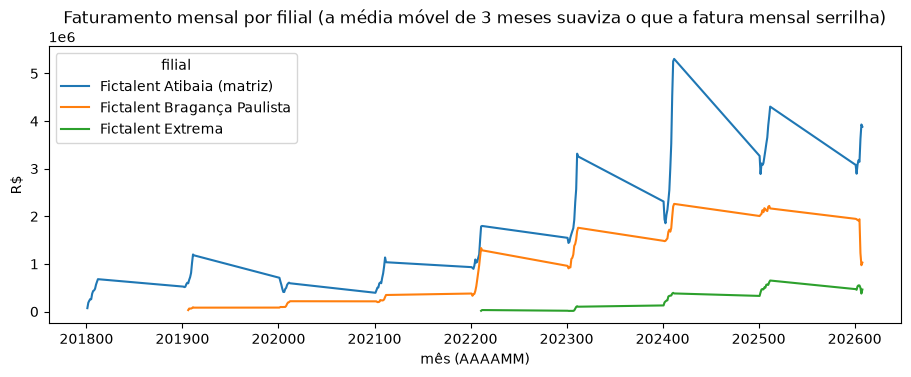

mes_id
2018    4,600,110.85
2019    9,384,825.54
2020    8,061,540.65
2021   11,150,725.59
2022   23,017,381.42
2023   39,844,266.14
2024   61,012,591.39
2025   73,130,943.24
2026   43,592,577.02
Name: faturamento_por_ano, dtype: float64

In [5]:
por_ano = serie.groupby(serie.mes_id // 100).faturamento.sum().rename("faturamento_por_ano")
largura = serie.pivot(index="mes_id", columns="filial", values="faturamento")
ax = largura.plot(title="Faturamento mensal por filial (a média móvel de 3 meses suaviza o que a fatura mensal serrilha)")
ax.set_xlabel("mês (AAAAMM)"); ax.set_ylabel("R$")
plt.show()
por_ano

## Nota Técnica

**Observado:** o faturamento mensal da matriz atinge o pico em dezembro de 2024 (5.305.470,58) e o de Bragança no mesmo mês (2.260.802,64); Extrema, aberta em 2022, só atinge o pico em dezembro de 2025 (651.354,34). A variação anual (o mesmo mês do ano anterior, pelo `LAG` de 12) fica negativa a partir de outubro de 2025 na matriz, dezembro de 2025 em Bragança e junho de 2026 em Extrema. As pessoas alocadas chegam ao máximo em novembro de 2024 na matriz (983) e em Bragança (407) e caem para 623 e 171 em agosto de 2026; os clientes ativos vão de 38 para 30 na matriz e de 22 para 10 em Bragança. No ano, o faturamento sobe de 4,6 milhões (2018) para 73,1 milhões (2025), e 2026 soma 43,6 milhões em oito meses.

**Por que importa:** a afirmação D1 fala de 2024 como o fim do crescimento, e a série diz mais fino: a receita ainda cresce em 2025 (o ano fecha 20% acima de 2024), mas o estoque de pessoas e de clientes para de crescer em novembro de 2024 e a comparação anual vira negativa no fim de 2025. Crescer em receita com menos pessoas e menos clientes é reajuste de preço, não crescimento de operação. O notebook de análise tem aqui o número de cada leitura.

**Ação:** levar a série mensal, não a anual, para a análise de D1: a resposta muda conforme a medida (receita, pessoas, clientes) e conforme o grão.

<a id="secao-3"></a>

# 3. O Pareto dos clientes

Para D2 e A1: quem carrega a receita de cada ano, com que margem, e quantos clientes fazem 80% dela. `RANK` dá a posição, a partição sem ordem dá o total do ano em toda linha (a participação) e a soma acumulada na ordem da receita desenha a curva de Pareto. `NTILE(4)` reparte os clientes do ano em quartis de margem.

In [6]:
pareto = mostrar("pareto_de_clientes")
pareto[pareto.ano == 2025].head(20)

pareto_de_clientes · D2 (margem por cliente e filial) e A1 (margem pelo porte do cliente)
Quais clientes carregam a receita de cada ano, com que margem, e quantos fazem 80% dela?
  janela: RANK() PARTITION BY ano ORDER BY receita DESC: a posição; empate repete e pula (1, 1, 3)
  janela: SUM(receita) OVER (PARTITION BY ano): sem ordem, o quadro é a partição inteira, o total do ano em toda linha
  janela: SUM(receita) ... ORDER BY receita DESC ROWS UNBOUNDED PRECEDING: o acumulado dos maiores até a linha, para a curva 80/20
  janela: NTILE(4) PARTITION BY ano ORDER BY margem percentual DESC: o quartil de margem de cada cliente


,ano,cliente,porte,receita,margem,margem_pct,posicao,participacao,participacao_acumulada,clientes_no_ano,quartil_de_margem
199,2025,Tedonor,GRANDE,"10,764,148.27","3,258,513.70",0.3027,1,0.1494,0.1494,57,4
200,2025,Fenugina,GRANDE,"9,568,409.22","2,456,348.36",0.2567,2,0.1328,0.2821,57,4
201,2025,Nabolux,GRANDE,"8,086,404.09","2,185,934.71",0.2703,3,0.1122,0.3944,57,4
202,2025,Detofeplan,MEDIA,"3,420,737.77","1,188,055.02",0.3473,4,0.0475,0.4418,57,2
203,2025,Cigina,MEDIA,"3,214,917.58","1,038,791.15",0.3231,5,0.0446,0.4864,57,3
204,2025,Brupibrapack,MEDIA,"2,597,285.51","988,804.27",0.3807,6,0.0360,0.5225,57,1
205,2025,Mebalux,MEDIA,"2,484,102.30","825,108.03",0.3322,7,0.0345,0.5569,57,3
206,2025,Ficetex,MEDIA,"2,451,306.79","802,093.40",0.3272,8,0.0340,0.5910,57,3
207,2025,Cudebolis,MEDIA,"2,082,940.11","623,572.37",0.2994,9,0.0289,0.6199,57,4
208,2025,Gorulatec,MEDIA,"1,902,307.85","618,394.99",0.3251,10,0.0264,0.6463,57,3


In [7]:
def concentracao(g: pd.DataFrame) -> pd.Series:
    tres = g.head(3)
    return pd.Series({
        "clientes": len(g), "clientes_ate_80_pct": int((g.participacao_acumulada <= 0.8).sum() + 1),
        "participacao_dos_3_maiores": float(tres.participacao.sum()),
        "margem_dos_3_maiores": float(tres.margem.sum() / tres.receita.sum()),
        "margem_dos_demais": float(g.iloc[3:].margem.sum() / g.iloc[3:].receita.sum()),
    })
pareto.groupby("ano").apply(concentracao, include_groups=False)

,clientes,clientes_ate_80_pct,participacao_dos_3_maiores,margem_dos_3_maiores,margem_dos_demais
ano,,,,,
2018,9.0000,4.0000,0.7830,0.3106,0.3442
2019,14.00,5.0000,0.7019,0.2952,0.3490
2020,18.00,7.0000,0.5886,0.2835,0.3450
2021,20.00,8.0000,0.4380,0.2863,0.3344
2022,31.00,13.00,0.3318,0.2761,0.3277
2023,45.00,14.00,0.3951,0.2872,0.3475
2024,62.00,18.00,0.3854,0.2748,0.3416
2025,57.00,17.00,0.3944,0.2780,0.3335
2026,52.00,14.00,0.3946,0.2810,0.3201


In [8]:
pareto[pareto.ano == 2025].groupby("porte").apply(
    lambda g: pd.Series({"clientes": len(g), "receita": float(g.receita.sum()), "margem_pct": float(g.margem.sum() / g.receita.sum())}),
    include_groups=False,
).sort_values("receita", ascending=False)

,clientes,receita,margem_pct
porte,,,
MEDIA,26.00,"36,293,948.52",0.3263
GRANDE,3.0000,"28,418,961.58",0.2780
EPP,22.00,"6,669,463.06",0.3661
ME,6.0000,"681,863.71",0.3969


## Nota Técnica

**Observado:** em 2025, 57 clientes faturaram, e 17 fazem 80% da receita; os três maiores (todos de porte grande) fazem 39,4% dela com margem de 27,8%, contra 33,3% nos demais. A concentração caiu com o crescimento (os três maiores eram 78,3% da receita em 2018 e 33,2% em 2022) e voltou a subir desde 2023 (39,5%, 38,5%, 39,4%, 39,5%). Por porte, em 2025: os 3 grandes rendem 28,4 milhões a 27,8% de margem; os 26 médios, 36,3 milhões a 32,6%; os 22 EPP, 6,7 milhões a 36,6%; as 6 ME, 0,7 milhão a 39,7%.

**Por que importa:** a margem cai com o porte do cliente em todos os anos, e a receita está concentrada nos clientes de menor margem. É o número que a afirmação A1 (margem pelo porte do cliente) pede, e o que a D2 precisa para separar "margem baixa" de "cliente grande". O `NTILE` deixa o quartil de margem na linha do cliente, pronto para cruzar com o porte e com a inadimplência (`fato_recebimento`).

**Ação:** no notebook de análise, cruzar o quartil de margem com a inadimplência por cliente antes de concluir sobre A1; a margem sozinha não diz se o cliente grande é bom negócio.

<a id="secao-4"></a>

# 4. O aviso e o fim

Para D3 ("a perda de contratos começou em 2025, com os avisos"): em cada contrato encerrado, quando veio o primeiro aviso de rescisão, quantas reclamações houve nos seis meses finais e a ocupação do contrato caiu antes do fim. As duas médias de ocupação usam quadros diferentes sobre a mesma janela (os seis meses finais; o ano anterior a eles), lidas na última linha do contrato, que `ROW_NUMBER` numerando do fim encontra sem subconsulta.

In [9]:
aviso = mostrar("o_aviso_e_o_fim")
aviso["ano_do_fim"] = pd.to_datetime(aviso.fim).dt.year
print(f"{len(aviso)} contratos encerrados; {int(aviso.primeiro_aviso.notna().sum())} com aviso de rescisão registrado; "
      f"antecedência do aviso: mínimo {aviso.meses_de_antecedencia.min()}, mediana {aviso.meses_de_antecedencia.median()}, máximo {aviso.meses_de_antecedencia.max()} meses")
print(f"{int(aviso.ocupacao_6m_finais.notna().sum())} com ocupação medida (tinham posto): "
      f"{int((aviso.queda_de_ocupacao < -0.05).sum())} caíram mais de 5 pontos nos seis meses finais, "
      f"{int((aviso.queda_de_ocupacao < -0.10).sum())} mais de 10, {int((aviso.queda_de_ocupacao > 0).sum())} subiram")
aviso.groupby("ano_do_fim").agg(
    encerrados=("numero", "count"), com_aviso=("primeiro_aviso", lambda x: int(x.notna().sum())),
    reclamacoes_6m_finais=("reclamacoes_6m_finais", "sum"), reclamacoes_antes=("reclamacoes_antes", "sum"),
    queda_media_de_ocupacao=("queda_de_ocupacao", "mean"),
)

o_aviso_e_o_fim · D3 (a perda de contratos começou antes do que a diretoria diz?)
Em cada contrato encerrado, quando veio o primeiro aviso de rescisão, quantas reclamações houve nos seis meses finais, e a ocupação caiu antes do fim?
  janela: AVG(ocupacao) ROWS BETWEEN 5 PRECEDING AND CURRENT ROW: a média dos seis meses finais, lida na última linha do contrato
  janela: AVG(ocupacao) ROWS BETWEEN 17 PRECEDING AND 6 PRECEDING: um quadro que termina antes da linha atual, para comparar com o período anterior
  janela: ROW_NUMBER() PARTITION BY contrato ORDER BY mês DESC: numera do fim; `do_fim = 1` escolhe o último mês sem subconsulta
76 contratos encerrados; 55 com aviso de rescisão registrado; antecedência do aviso: mínimo 0, mediana 1.0, máximo 1 meses
45 com ocupação medida (tinham posto): 8 caíram mais de 5 pontos nos seis meses finais, 4 mais de 10, 24 subiram


,encerrados,com_aviso,reclamacoes_6m_finais,reclamacoes_antes,queda_media_de_ocupacao
ano_do_fim,,,,,
2019,4,2,0,0,-0.0272
2020,13,8,4,6,0.0265
2021,2,2,2,5,0.0062
2022,2,1,3,20,0.0197
2023,4,2,0,0,-0.0325
2024,7,6,9,13,0.0358
2025,22,16,48,77,0.0162
2026,22,18,124,333,-0.0236


In [10]:
aviso[aviso.queda_de_ocupacao < -0.10][["numero", "cliente", "fim", "primeiro_aviso", "reclamacoes_6m_finais", "ocupacao_12m_anteriores", "ocupacao_6m_finais", "queda_de_ocupacao"]]

,numero,cliente,fim,primeiro_aviso,reclamacoes_6m_finais,ocupacao_12m_anteriores,ocupacao_6m_finais,queda_de_ocupacao
46,CT-2023-0006,Bogulux,2025-09-16,2025-08-17,0,0.9301,0.7763,-0.1538
60,CT-2024-0014,Pedusul,2026-01-17,2025-12-18,0,0.9516,0.6104,-0.3412
61,CT-2024-0016,Ragufina,2026-01-17,2025-12-18,1,0.9385,0.8228,-0.1157
70,CT-2023-0011,Votrecunor,2026-05-29,2026-04-29,0,0.7779,0.4706,-0.3073


## Nota Técnica

**Observado:** 76 contratos encerrados até o horizonte; 55 têm aviso de rescisão registrado, sempre um mês antes do fim (mediana 1, máximo 1): o aviso é formalidade de prazo, não sinal antecipado. Os encerramentos se concentram em 2025 (22) e 2026 (22, até setembro), contra 2 a 13 por ano antes. As reclamações nos seis meses finais acompanham: 48 em 2025 e 124 em 2026, contra 9 em 2024. A ocupação nos seis meses finais, medida em 45 contratos com posto, caiu mais de 5 pontos em 8 e mais de 10 pontos em 4 (Bogulux, Pedusul, Ragufina, Votrecunor), e subiu em 24.

**Por que importa:** D3 diz que a perda começou em 2025 com os avisos. O número confirma a concentração em 2025 e 2026, mas o aviso chega um mês antes em todos os casos: quem quiser antecipar a perda tem de olhar para as reclamações dos seis meses finais (que crescem antes do aviso) e, em parte dos contratos, para a ocupação. O sinal está na operação, não no comercial.

**Ação:** para D3, construir no notebook de análise a série "reclamações nos seis meses anteriores" por contrato ativo hoje, com a mesma janela, e listar os que já estão no padrão dos encerrados.

<a id="secao-5"></a>

# 5. O mercado e o serviço

Para D4 ("a queda é do mercado"): o CAGED do segmento (grupo 78) nos três municípios, mês a mês, ao lado do que a Fictalent fez no mesmo mês (vagas abertas, dias até preencher, reclamações, contratos encerrados), com o saldo de três e seis meses antes na mesma linha. A segunda consulta mede a defasagem: a correlação entre o saldo do CAGED de k meses antes e cada série da Fictalent, para k de 0 a 6; o deslocamento do `LAG` tem de ser constante, por isso são sete seleções unidas.

In [11]:
mercado = mostrar("mercado_e_servico")
mercado["ano"] = mercado.mes_id // 100
mercado.groupby("ano").agg(
    admissoes_mercado=("admissoes_mercado", "sum"), desligamentos_mercado=("desligamentos_mercado", "sum"), saldo_mercado=("saldo_mercado", "sum"),
    vagas_abertas=("vagas_abertas", "sum"), dias_ate_preencher_mediana=("dias_ate_preencher_mediana", "median"),
    reclamacoes=("reclamacoes", "sum"), contratos_encerrados=("contratos_encerrados", "sum"),
)

mercado_e_servico · D4 (a queda é do mercado?)
Mês a mês, o que o mercado da região fez (CAGED) e o que a Fictalent fez ao mesmo tempo: vagas, tempo de preenchimento, reclamações, contratos perdidos?
  janela: AVG(saldo_mercado) ROWS BETWEEN 2 PRECEDING AND CURRENT ROW, sem partição: uma série só, a região inteira
  janela: LAG(saldo_mercado, 3) e LAG(saldo_mercado, 6): o mercado de três e seis meses antes, na mesma linha do mês


,admissoes_mercado,desligamentos_mercado,saldo_mercado,vagas_abertas,dias_ate_preencher_mediana,reclamacoes,contratos_encerrados
ano,,,,,,,
2023,"11,025.00","10,483.00",542.00,3121,11.50,105,4
2024,"15,235.00","13,697.00","1,538.00",4497,14.00,249,7
2025,"17,277.00","16,446.00",831.00,4113,17.00,381,22


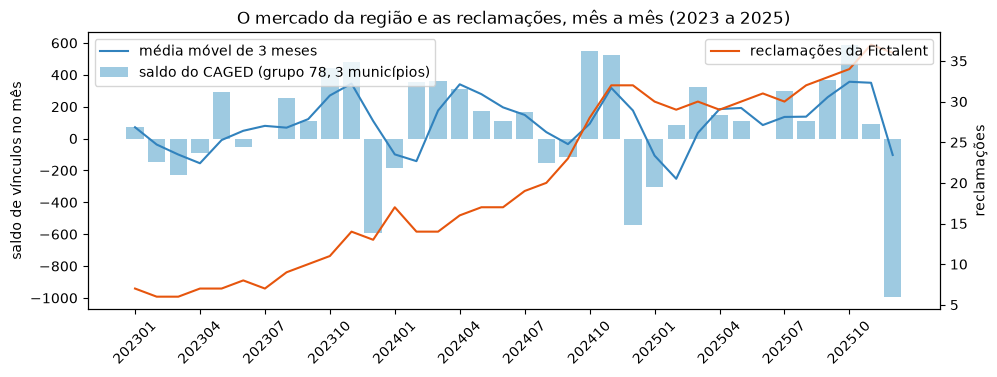

defasagem_do_mercado · D4 (a defasagem medida em meses)
Com quantos meses de atraso o serviço acompanha o mercado (a correlação entre o saldo do CAGED de k meses antes e cada série da Fictalent, para k de 0 a 6)?
  janela: LAG(saldo_mercado, k) OVER (ORDER BY mes_id), uma vez para cada k de 0 a 6: o deslocamento é constante por exigência do SQL, por isso são sete seleções unidas
  janela: CORR(...) é agregação, não janela: ela recebe o par (mercado deslocado, série do mês) e resume os meses num número por defasagem


,defasagem_meses,corr_reclamacoes,corr_dias_ate_preencher,corr_contratos_encerrados,corr_vagas_abertas,meses_comparados
0,0,-0.0099,-0.0307,-0.2313,0.2226,36
1,1,0.1882,0.0276,0.1016,0.2762,35
2,2,0.2078,0.0836,0.1587,0.1598,34
3,3,0.1302,0.0853,0.1015,0.0420,33
4,4,0.0806,-0.0681,-0.0704,-0.0043,32
5,5,0.1008,0.0649,-0.1689,0.2014,31
6,6,0.0975,0.1605,0.1866,0.2411,30


In [12]:
eixo = mercado.set_index("mes_id")
fig, esq = plt.subplots()
esq.bar(range(len(eixo)), eixo.saldo_mercado, color="#9ecae1", label="saldo do CAGED (grupo 78, 3 municípios)")
esq.plot(range(len(eixo)), eixo.saldo_mercado_3m, color="#3182bd", label="média móvel de 3 meses")
esq.set_ylabel("saldo de vínculos no mês"); esq.set_xticks(range(0, len(eixo), 3)); esq.set_xticklabels(eixo.index[::3], rotation=45)
dir_ = esq.twinx(); dir_.plot(range(len(eixo)), eixo.reclamacoes, color="#e6550d", label="reclamações da Fictalent"); dir_.set_ylabel("reclamações")
esq.set_title("O mercado da região e as reclamações, mês a mês (2023 a 2025)"); esq.legend(loc="upper left"); dir_.legend(loc="upper right")
plt.show()
mostrar("defasagem_do_mercado")

## Nota Técnica

**Observado:** o mercado do segmento na região admitiu mais a cada ano (11.025 em 2023, 15.235 em 2024, 17.277 em 2025) e manteve saldo positivo (542, 1.538, 831). No mesmo arco, as reclamações da Fictalent foram de 105 para 249 e 381, os dias até preencher de 11,5 para 14 e 17, e os contratos encerrados de 4 para 7 e 22. A correlação entre o saldo do CAGED deslocado e as séries da Fictalent é fraca em toda defasagem de 0 a 6 meses: o maior valor com as reclamações é 0,21 (dois meses), com os dias até preencher 0,16 (seis meses), e com os contratos encerrados varia de -0,23 a 0,19.

**Por que importa:** D4 atribui a queda ao mercado. A régua de fora diz o contrário no que ela mede: o mercado de vínculos do segmento cresceu nos três anos e o seu ritmo mensal explica pouco do que a Fictalent viveu. Isso não encerra a pergunta (o CAGED mede vínculos, não demanda por terceirização), mas tira do mercado o papel de explicação principal, e deixa a série de qualidade (reclamações, dias até preencher) como candidata.

**Ação:** no notebook de análise, repetir a defasagem com o índice sazonal (`dados/publicos/caged/indice_sazonal.csv`) para separar o ritmo do ano da tendência; e pedir ao cliente a série de demanda que ele tiver (propostas recebidas), que o CAGED não contém.

<a id="secao-6"></a>

# 6. O funil por trimestre

Para D5 ("contratar mais assistente resolveria"): a conversão de cada etapa por trimestre, a mediana de dias no funil e a comparação com o mesmo trimestre do ano anterior (`LAG` de 4 numa série trimestral). O `RANK` sem partição ordena os 35 trimestres pela rapidez.

In [13]:
funil = mostrar("funil_por_trimestre")
funil.tail(12)

funil_por_trimestre · D5 (contratar mais assistente resolveria?)
A cada trimestre, quantas candidaturas chegaram a cada etapa, quantas viraram admissão, em quantos dias, e como isso se compara ao mesmo trimestre do ano anterior?
  janela: LAG(x, 4) OVER (ORDER BY ano, trimestre): o mesmo trimestre do ano anterior, numa série trimestral sem buraco
  janela: RANK() OVER (ORDER BY dias_no_funil_mediana): a posição sem partição, entre todos os trimestres


,ano,trimestre,candidaturas,entrevistadas,encaminhadas,aprovadas,admitidas,aprovadas_que_nao_comecaram,conversao_da_triagem,conversao_da_entrevista,conversao_da_admissao,conversao_total,variacao_anual_da_conversao,dias_no_funil_mediana,variacao_anual_dos_dias,posicao_pela_rapidez
23,2023,4,14937,8675,3583,1191,1097,94,0.5808,0.1373,0.9211,0.0734,-0.0007,3.0000,0.0000,7
24,2024,1,10441,6013,2315,695,584,111,0.5759,0.1156,0.8403,0.0559,-0.0070,3.0000,0.0000,7
25,2024,2,13179,7646,3069,901,773,128,0.5802,0.1178,0.8579,0.0587,-0.0029,3.0000,0.0000,7
26,2024,3,18163,10638,4317,1427,1303,124,0.5857,0.1341,0.9131,0.0717,0.0035,3.0000,0.0000,7
27,2024,4,22530,13018,5187,1629,1506,123,0.5778,0.1251,0.9245,0.0668,-0.0066,3.0000,0.0000,7
28,2025,1,13119,7562,2929,851,743,108,0.5764,0.1125,0.8731,0.0566,0.0007,3.0000,0.0000,7
29,2025,2,12830,7412,2823,832,717,115,0.5777,0.1123,0.8618,0.0559,-0.0028,3.0000,0.0000,7
30,2025,3,14989,8699,3251,997,893,104,0.5804,0.1146,0.8957,0.0596,-0.0122,3.0000,0.0000,7
31,2025,4,16803,9763,3723,1158,1040,118,0.5810,0.1186,0.8981,0.0619,-0.0050,3.0000,0.0000,7
32,2026,1,14995,8724,3295,940,745,195,0.5818,0.1077,0.7926,0.0497,-0.0070,3.0000,0.0000,7


In [14]:
funil.groupby("ano").agg(
    candidaturas=("candidaturas", "sum"), conversao_total_media=("conversao_total", "mean"),
    conversao_da_admissao_media=("conversao_da_admissao", "mean"), aprovadas_que_nao_comecaram=("aprovadas_que_nao_comecaram", "sum"),
    dias_no_funil_mediana=("dias_no_funil_mediana", "median"),
)

,candidaturas,conversao_total_media,conversao_da_admissao_media,aprovadas_que_nao_comecaram,dias_no_funil_mediana
ano,,,,,
2018,6677,0.0604,0.7351,142,3.0000
2019,13637,0.0510,0.7136,264,3.0000
2020,9015,0.0528,0.7561,148,2.5000
2021,14945,0.0644,0.8413,165,3.0000
2022,28831,0.0668,0.8653,279,3.0000
2023,44446,0.0666,0.8830,375,3.0000
2024,64313,0.0633,0.8840,486,3.0000
2025,57741,0.0585,0.8822,445,3.0000
2026,43000,0.0415,0.7845,412,3.0000


## Nota Técnica

**Observado:** a conversão total (admitidas sobre candidaturas) fica entre 5,1% e 6,7% de 2018 a 2025 e cai para 4,2% em 2026; a conversão da admissão (admitidas sobre aprovadas) sobe de 73,5% em 2018 para 88% entre 2023 e 2025 e cai para 78,4% em 2026, com 195 e 210 aprovadas que não começaram nos dois primeiros trimestres de 2026, contra 104 a 128 por trimestre em 2024 e 2025. A mediana de dias no funil é 3 em todos os anos (2 ou 3 por trimestre): o funil não ficou mais lento. O terceiro trimestre de 2026 está incompleto (termina no horizonte, 10 de setembro) e por isso tem conversão menor.

**Por que importa:** D5 propõe mais assistentes para o funil. O número diz que o funil não demora mais do que demorava; o que mudou em 2026 foi a ponta: a aprovada que não começa. Mais gente na triagem não muda a admissão. A pergunta que o dado sugere é outra: por que a pessoa aprovada em 2026 não aparece no primeiro dia.

**Ação:** levar para a análise de D5 a série trimestral de `aprovadas_que_nao_comecaram` por filial e função (o `fato_candidatura` tem as duas), e descontar o terceiro trimestre de 2026 até o mês fechar.

<a id="secao-7"></a>

# 7. O informado contra o apurado

Para D6 ("depois de 2022 os relatórios pararam de bater"): mês a mês e por filial, a diferença entre o faturamento informado pela gerência (a planilha) e o apurado na operação (as faturas), desde quando diverge e por quantos meses seguidos. A sequência é achada por gaps-and-islands: a diferença entre duas numerações de linha (`ROW_NUMBER` por filial e por filial e estado) é constante dentro de uma sequência de meses iguais, e vira a partição que conta o tamanho dela.

In [15]:
informado = mostrar("informado_contra_apurado")
print(f"{len(informado)} meses informados; {int(informado.diverge.sum())} divergem mais de 1% do apurado")
antes = informado[informado.mes_id < 202301]
print(f"antes de 2023: {len(antes)} meses, {int((antes.diferenca_faturamento != 0).sum())} com alguma diferença, a maior de {antes.divergencia_pct.max():.2%}")
informado.groupby("filial").agg(
    primeiro_mes_divergente=("mes_id", lambda x: int(x[informado.loc[x.index, "diverge"]].min())),
    ultimo_mes_que_bateu=("mes_id", lambda x: int(x[~informado.loc[x.index, "diverge"]].max())),
    maior_sequencia=("meses_seguidos", "max"), diferenca_acumulada=("diferenca_acumulada", "last"),
    divergencia_media_quando_diverge=("divergencia_pct", lambda x: float(x[informado.loc[x.index, "diverge"]].mean())),
)

informado_contra_apurado · D6 (depois de 2022 os relatórios pararam de bater)
Mês a mês e por filial, quanto o faturamento informado pela gerência diverge do apurado na operação, desde quando, e por quantos meses seguidos?
  janela: ROW_NUMBER() PARTITION BY filial ORDER BY mês menos ROW_NUMBER() PARTITION BY filial, diverge ORDER BY mês: o rótulo da ilha (gaps-and-islands)
  janela: SUM(indicador) PARTITION BY filial ORDER BY mês: o acumulado de meses divergentes
  janela: COUNT(*) e MIN(mes_id) PARTITION BY filial, diverge, ilha: o tamanho e o início da sequência, sem agrupar a tabela
237 meses informados; 132 divergem mais de 1% do apurado
antes de 2023: 105 meses, 26 com alguma diferença, a maior de 0.69%


,primeiro_mes_divergente,ultimo_mes_que_bateu,maior_sequencia,diferenca_acumulada,divergencia_media_quando_diverge
filial,,,,,
Fictalent Atibaia (matriz),202301,202212,60,"-1,400,556.64",0.0540
Fictalent Bragança Paulista,202301,202212,44,"-1,928,039.19",0.0581
Fictalent Extrema,202301,202212,44,"-469,994.61",0.0568


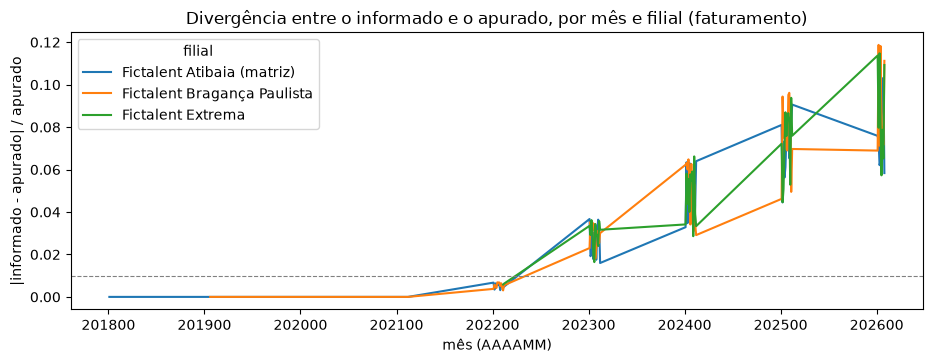

In [16]:
largura = informado.pivot(index="mes_id", columns="filial", values="divergencia_pct")
ax = largura.plot(title="Divergência entre o informado e o apurado, por mês e filial (faturamento)")
ax.axhline(0.01, color="grey", linestyle="--", linewidth=0.8); ax.set_ylabel("|informado - apurado| / apurado"); ax.set_xlabel("mês (AAAAMM)")
plt.show()

## Nota Técnica

**Observado:** 237 meses informados, 132 divergem mais de 1% do apurado. Antes de 2023, dos 105 meses, 26 têm alguma diferença e a maior é de 0,69%: a planilha batia. De janeiro de 2023 em diante, as três filiais divergem todo mês, sem interrupção (sequências de 60 meses na matriz, que inclui o consolidado até agosto de 2026, e de 44 em Bragança e Extrema), com divergência média de 5,4% a 5,8% e diferença acumulada de 1,40 milhão na matriz, 1,93 milhão em Bragança e 0,47 milhão em Extrema, sempre com o informado abaixo do apurado.

**Por que importa:** D6 está certa na data e no sentido: o último mês que bateu foi dezembro de 2022 e, desde então, a gerência informa menos do que a operação fatura. A janela de sequência mostra que não é ruído: é um desvio contínuo, de um dígito percentual, nas três filiais ao mesmo tempo, o que aponta para o processo da planilha e não para um erro isolado.

**Ação:** levar para a análise de D6 as mesmas sequências para custo e headcount (o `fato_resultado_mes` tem as quatro diferenças) e perguntar ao cliente o que mudou no fechamento gerencial em janeiro de 2023.

<a id="secao-8"></a>

# 8. A coorte de 90 dias

O indicador de rotatividade pede a parte de cada coorte de admissão que saiu cedo: pedido ou dispensa em até 90 dias (o fim do contrato temporário e a efetivação pelo cliente não são falha). A taxa dos últimos doze meses é ponderada: duas somas no mesmo quadro de doze linhas, divididas depois, para que meses pequenos não pesem como meses grandes. A coorte só é completa quando o nonagésimo dia do último admitido já passou.

In [17]:
coorte = mostrar("coorte_de_90_dias")
coorte["ano"] = coorte.mes_de_admissao // 100
completas = coorte[coorte.coorte_completa]
completas.groupby("ano").agg(admitidos=("admitidos", "sum"), saidas_precoces=("sairam_em_90_dias", "sum"), encerrados_em_90_dias=("encerrados_em_90_dias", "sum")).assign(
    taxa_precoce=lambda d: d.saidas_precoces / d.admitidos, taxa_de_encerramento=lambda d: d.encerrados_em_90_dias / d.admitidos
)

coorte_de_90_dias · indicador de rotatividade (turnover em 90 dias) e D4
De quem foi admitido em cada mês, que parte saiu cedo (pedido ou dispensa em até 90 dias), e como essa taxa anda numa média de doze meses?
  janela: SUM(...) OVER doze_meses, com ROWS BETWEEN 11 PRECEDING AND CURRENT ROW: duas somas no mesmo quadro, divididas depois, para a taxa ponderada (a média das taxas daria peso igual a meses de tamanhos diferentes)
  janela: LAG(taxa, 12) OVER (ORDER BY mês): a mesma coorte um ano antes


,admitidos,saidas_precoces,encerrados_em_90_dias,taxa_precoce,taxa_de_encerramento
ano,,,,,
2018,352,54,168,0.1534,0.4773
2019,726,110,468,0.1515,0.6446
2020,480,70,355,0.1458,0.7396
2021,940,148,715,0.1574,0.7606
2022,1920,287,1501,0.1495,0.7818
2023,2930,557,2353,0.1901,0.8031
2024,4169,994,3165,0.2384,0.7592
2025,3369,1006,2293,0.2986,0.6806
2026,1131,358,721,0.3165,0.6375


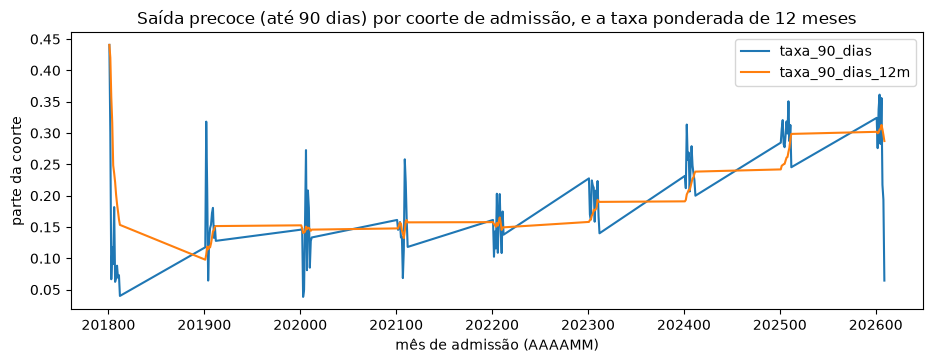

,mes_de_admissao,admitidos,sairam_em_90_dias,encerrados_em_90_dias,coorte_completa,taxa_90_dias,taxa_90_dias_12m,variacao_anual,ano
101,202606,399,142,211,False,0.3559,0.3129,0.0596,2026
102,202607,230,50,106,False,0.2174,0.3059,-0.1011,2026
103,202608,284,55,69,False,0.1937,0.2970,-0.1056,2026
104,202609,62,4,4,False,0.0645,0.2872,-0.2861,2026


In [18]:
ax = coorte.set_index("mes_de_admissao")[["taxa_90_dias", "taxa_90_dias_12m"]].plot(title="Saída precoce (até 90 dias) por coorte de admissão, e a taxa ponderada de 12 meses")
ax.set_ylabel("parte da coorte"); ax.set_xlabel("mês de admissão (AAAAMM)")
plt.show()
coorte.tail(4)

## Nota Técnica

**Observado:** nas coortes completas, a saída precoce fica entre 14,6% e 15,7% de 2018 a 2022, sobe para 19,0% em 2023, 23,8% em 2024, 29,9% em 2025 e 31,7% em 2026. A taxa ponderada de doze meses, que suaviza o mês, segue a mesma subida. O encerramento em até 90 dias por qualquer motivo (inclusive fim de contrato) é maior, entre 48% e 80%, e cai desde 2023, porque o fim natural do temporário deixou de ser a saída dominante. As quatro últimas coortes não estão completas e não entram na leitura.

**Por que importa:** é o indicador de rotatividade do `docs/01` com a definição explícita: saída precoce é a que a Fictalent pode evitar. Ele dobrou entre 2022 e 2025, e é uma das séries que a análise de D4 vai colocar ao lado do mercado e das reclamações.

**Ação:** cruzar a coorte com a função e o cliente (`fato_vinculo` tem a função; `fato_alocacao`, o cliente) para saber onde a saída precoce se concentra.

<a id="secao-9"></a>

# 9. Os postos descobertos em sequência

O indicador de dias de posto descoberto, lido como sequência: meses inteiros seguidos em que o posto ficou abaixo de 90% de ocupação. O mesmo gaps-and-islands da seção 7, agora por posto; `DENSE_RANK` ordena as sequências sem pular posição em empate.

In [19]:
ilhas = mostrar("postos_descobertos_em_sequencia")
print(f"{len(ilhas)} sequências em {ilhas.posto_id.nunique()} postos (de {int(con.execute('SELECT count(*) FROM gold.dim_posto WHERE id > 0').fetchall()[0][0])}); "
      f"{int((ilhas.meses_seguidos >= 12).sum())} com um ano ou mais, {int((ilhas.meses_seguidos >= 24).sum())} com dois anos ou mais; "
      f"{ilhas.posicao_dias_descobertos.sum():,.0f} posição-dias descobertos no total".replace(",", "."))
ilhas.head(10)

postos_descobertos_em_sequencia · indicador de dias de posto descoberto e D2
Quais postos ficaram abaixo de 90% de ocupação por mais meses seguidos, em que cliente, e quantos posição-dias faltaram nessa sequência?
  janela: ROW_NUMBER() PARTITION BY posto menos ROW_NUMBER() PARTITION BY posto, descoberto: o rótulo da sequência; a série de meses do posto não tem buraco, condição do truque
  janela: DENSE_RANK() OVER (ORDER BY meses_seguidos DESC): a posição sem pulos em empate
859 sequências em 417 postos (de 694); 33 com um ano ou mais. 14 com dois anos ou mais; 117.391 posição-dias descobertos no total


,cliente,posto_id,inicio,fim,meses_seguidos,posicao_dias_descobertos,ocupacao_media,posicao
0,Mebalux,112,202103,202608,66,"6,863.00",0.6892,1
1,Putrudona,160,202202,202602,49,"1,989.00",0.7776,2
2,Brupibrapack,174,202204,202512,45,"1,522.00",0.7780,3
3,Trigetec,258,202302,202608,43,"2,831.00",0.4589,4
4,Vinipamar,179,202304,202608,41,"2,975.00",0.5237,5
5,Ficetex,66,202308,202608,37,"1,333.00",0.8686,6
6,Fenugina,268,202309,202606,34,"4,812.00",0.7675,7
7,Fenugina,262,202312,202606,31,"2,524.00",0.7767,8
8,Ditotec,382,202405,202608,28,901.00,0.4720,9
9,Ferononor,368,202406,202608,27,"3,099.00",0.6573,10


In [20]:
ilhas.groupby("cliente").agg(sequencias=("posto_id", "count"), posicao_dias_descobertos=("posicao_dias_descobertos", "sum"), maior_sequencia=("meses_seguidos", "max")).sort_values("posicao_dias_descobertos", ascending=False).head(8)

,sequencias,posicao_dias_descobertos,maior_sequencia
cliente,,,
Fenugina,52,"24,542.00",34
Mebalux,43,"13,238.00",66
Nabolux,39,"12,374.00",19
Vinipamar,36,"7,854.00",41
Ferononor,9,"5,104.00",27
Petara,7,"4,628.00",27
Putrudona,32,"4,498.00",49
Gorulatec,19,"4,314.00",23


## Nota Técnica

**Observado:** 859 sequências de posto descoberto em 417 dos 694 postos; 33 duram um ano ou mais e 14, dois anos ou mais. A maior é um posto da Mebalux, descoberto por 66 meses seguidos, de março de 2021 a agosto de 2026, com 6.863 posição-dias faltantes e ocupação média de 68,9%. Somadas, as sequências deixaram 117.391 posição-dias descobertos; a Fenugina concentra 24.542 deles, seguida de Mebalux (13.238) e Nabolux (12.374), os três maiores clientes.

**Por que importa:** o posto que fica descoberto por anos não é acidente de um mês; é um posto que a Fictalent não consegue preencher, e está nos clientes que carregam a receita (seção 3). Para D2, é a ponte entre a margem do posto e a ocupação: o posto descoberto fatura menos e custa reposição.

**Ação:** cruzar as sequências longas com a função do posto e com as reclamações do contrato (`fato_ocorrencia` tem o posto), e pôr as 14 sequências de dois anos ou mais na pauta com o cliente.

<a id="secao-10"></a>

# 10. Fechamento

O que as nove consultas entregam, e o que fica para o notebook de análise.

## Nota Técnica de fechamento

**O que foi examinado:** as 25 tabelas da gold, por nove consultas analíticas com funções de janela, cada uma ligada a uma afirmação ou indicador do `docs/01` e com a partição, a ordem e o quadro declarados. O SQL mora em `rh_fictalent.gold.analitico`, roda pela linha de comando e tem a semântica de cada janela provada em teste num cenário pequeno.

**O que os números dizem, sem concluir:** o estoque de pessoas e clientes para de crescer em novembro de 2024 e a receita, em 2025 (D1); a receita está concentrada nos clientes grandes, que têm a menor margem (D2, A1); o aviso de rescisão chega um mês antes do fim em todos os contratos, e o sinal antecipado está nas reclamações e, em parte, na ocupação (D3); o mercado do segmento cresceu nos três anos do CAGED e o ritmo dele explica pouco das séries da Fictalent em qualquer defasagem até seis meses (D4); o funil não ficou mais lento, mas a aprovada que não começa dobrou em 2026 (D5); a planilha da gerência bateu até dezembro de 2022 e diverge todo mês desde janeiro de 2023, nas três filiais, sempre para menos (D6); a saída precoce dobrou entre 2022 e 2025 e 14 postos ficaram descobertos por dois anos ou mais, nos maiores clientes.

**O que fica para o notebook de análise:** as conclusões sobre as sete afirmações, com o olhar de quem conhece o caso; as mesmas janelas aplicadas por filial, função e cliente onde este notebook ficou no agregado; e a defasagem repetida com o índice sazonal do CAGED.

**Ação:** nenhuma pendência técnica; as consultas estão versionadas, testadas e documentadas no `docs/16` (card 7.9).